# DeepBranchAI Demo: Lung Vasculature Segmentation

This notebook downloads everything automatically, segments VESSEL12 volume 21, and validates against expert annotations. Just click **Run All**.

In [1]:
# ============================================================
# CONFIGURATION - paths are rooted at this repository
# ============================================================
from pathlib import Path
import os

def find_repo_root(start=None):
    start = Path.cwd().resolve() if start is None else Path(start).resolve()
    for candidate in (start, *start.parents):
        if (candidate / 'deepbranchai_utils.py').exists() and (candidate / 'README.md').exists():
            return candidate
    raise RuntimeError('Could not find repository root')

REPO_DIR = find_repo_root()
BASE_DIR = str(REPO_DIR)
# ============================================================

# Zenodo record base
ZENODO_BASE = 'https://zenodo.org/records/19363534/files'

# Individual weight/config files for VESSEL12
ZENODO_VESSEL12_WEIGHT = f'{ZENODO_BASE}/DeepBranchAI_VESSEL12_fold2.pth?download=1'
ZENODO_VESSEL12_PLANS  = f'{ZENODO_BASE}/DeepBranchAI_VESSEL12_nnUNetPlans.json?download=1'
ZENODO_VESSEL12_DATASET = f'{ZENODO_BASE}/DeepBranchAI_VESSEL12_dataset.json?download=1'

# Demo data (VESSEL12_21 volume + annotations)
ZENODO_DEMO_URL = f'{ZENODO_BASE}/DeepBranchAI_demo_data.zip?download=1'
# ============================================================

In [2]:
import sys, os
if BASE_DIR not in sys.path:
    sys.path.insert(0, BASE_DIR)

from deepbranchai_utils import setup_environment, check_gpu, download_and_extract, install_weights

paths = setup_environment(BASE_DIR)
print()
gpu_ok = check_gpu()

PyTorch version:  2.7.1+cu118
CUDA available:   True
CUDA version:     11.8
GPU:              NVIDIA RTX A6000
VRAM:             51.5 GB


## Step 1: Download Weights and Demo Data

In [3]:
import urllib.request
from pathlib import Path

print('--- Model Weights ---')

# Create directory structure that install_weights() expects
extract_dir = paths['weights'] / 'DeepBranchAI_Zenodo'
weight_dir  = extract_dir / 'DeepBranchAI_VESSEL12_weights'
config_dir  = extract_dir / 'configs'
weight_dir.mkdir(parents=True, exist_ok=True)
config_dir.mkdir(parents=True, exist_ok=True)

# Download individual files
files_to_download = [
    (ZENODO_VESSEL12_WEIGHT,  weight_dir / 'DeepBranchAI_VESSEL12_fold2.pth'),
    (ZENODO_VESSEL12_PLANS,   config_dir / 'DeepBranchAI_VESSEL12_nnUNetPlans.json'),
    (ZENODO_VESSEL12_DATASET, config_dir / 'DeepBranchAI_VESSEL12_dataset.json'),
]

for url, dst in files_to_download:
    if not dst.exists():
        print(f'  Downloading {dst.name} ...')
        urllib.request.urlretrieve(url, str(dst))
        print(f'  Saved to {dst}')
    else:
        print(f'  Already downloaded: {dst.name}')

# Install weights into nnU-Net structure
install_weights(
    extract_dir, paths['nnUNet_results'], paths['nnUNet_preprocessed'], paths['nnUNet_raw'],
    dataset_name='Dataset3005_Mitochondria',
    trainer_dir='nnUNetTrainer_100epochs__nnUNetPlans__3d_fullres',
    weight_subdir='DeepBranchAI_VESSEL12_weights',
    config_prefix='DeepBranchAI_VESSEL12',
)

--- Model Weights ---
  Already downloaded: DeepBranchAI_VESSEL12_fold2.pth
  Already downloaded: DeepBranchAI_VESSEL12_nnUNetPlans.json
  Already downloaded: DeepBranchAI_VESSEL12_dataset.json
  fold_2 already installed
  DeepBranchAI_VESSEL12 setup complete.


In [ ]:
# Download demo data (VESSEL12_21 + annotations)
print('--- Demo Data ---')
download_and_extract(ZENODO_DEMO_URL, str(paths['data']), 'DeepBranchAI_demo_data.zip')

## Step 2: Load and Prepare the CT Volume

In [5]:
import numpy as np
import nibabel as nib
import tifffile
import matplotlib.pyplot as plt
import pandas as pd
import subprocess
import gc
from pathlib import Path

# Find the raw test volume
data_root = paths['data']
vessel21_tif = None
for p in data_root.rglob('VESSEL12_21_raw.tif'):
    vessel21_tif = p
    break

# Also try .mhd format (from Kaggle)
if vessel21_tif is None:
    for p in data_root.rglob('VESSEL12_21.mhd'):
        import SimpleITK as sitk
        img = sitk.ReadImage(str(p))
        vol_raw = sitk.GetArrayFromImage(img)
        vol_raw = ((vol_raw.astype(np.float32) - vol_raw.min()) / (vol_raw.max() - vol_raw.min()) * 255).astype(np.uint8)
        vessel21_tif = 'loaded_from_mhd'
        break

if vessel21_tif is None:
    raise FileNotFoundError('VESSEL12_21 not found. Check ZENODO_DEMO_URL.')

if vessel21_tif != 'loaded_from_mhd':
    print(f'Loading {vessel21_tif}')
    vol_raw = tifffile.imread(str(vessel21_tif))

print(f'Volume shape: {vol_raw.shape}, dtype: {vol_raw.dtype}')

Volume shape: (918, 1024, 1024), dtype: uint8


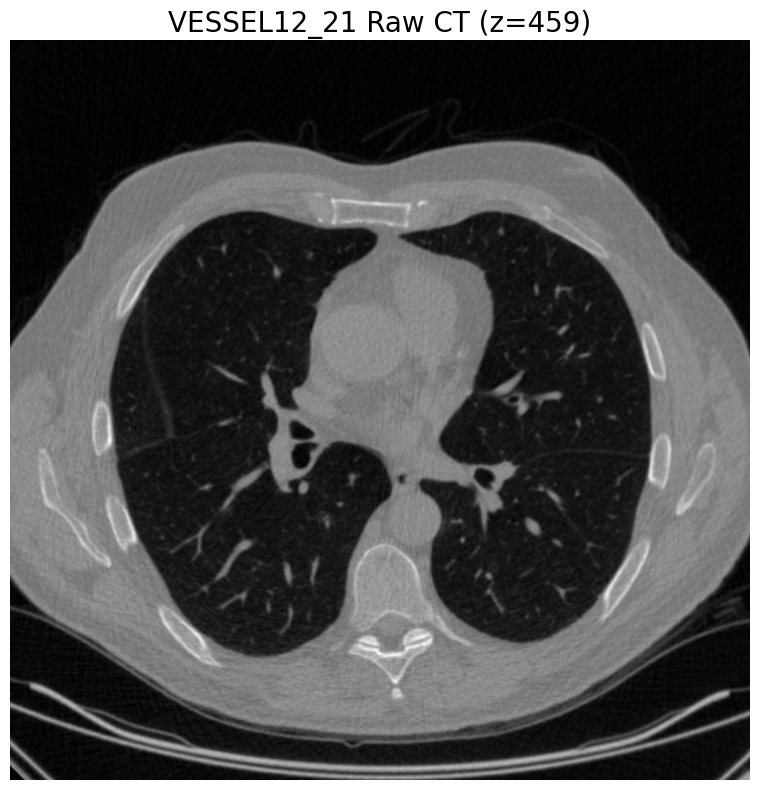

In [6]:
# Show the raw CT
D = vol_raw.shape[0]
mid = D // 2

fig, ax = plt.subplots(1, 1, figsize=(16, 8))
ax.imshow(vol_raw[mid], cmap='gray')
ax.set_title(f'VESSEL12_21 Raw CT (z={mid})', fontsize=20)
ax.axis('off')
plt.tight_layout()
plt.show()

In [7]:
# Convert to NIfTI for nnU-Net inference
INPUT_DIR  = paths['data'] / 'inference_input'
OUTPUT_DIR = paths['data'] / 'inference_output'
INPUT_DIR.mkdir(exist_ok=True)
OUTPUT_DIR.mkdir(exist_ok=True)

nii_path = INPUT_DIR / 'VESSEL12_21_0000.nii.gz'
if not nii_path.exists():
    nib.save(nib.Nifti1Image(vol_raw.astype(np.float32), np.eye(4)), str(nii_path))
    print(f'Saved NIfTI: {nii_path}')
else:
    print(f'NIfTI already exists')

NIfTI already exists


## Step 3: Run 3D Inference

In [8]:
output_nii = OUTPUT_DIR / 'VESSEL12_21.nii.gz'

if not output_nii.exists():
    import torch
    import functools

    # PyTorch 2.6+ defaults weights_only=True, which breaks nnU-Net checkpoints
    # containing numpy objects. Patch torch.load for this trusted Zenodo checkpoint.
    _original_torch_load = torch.load
    @functools.wraps(_original_torch_load)
    def _patched_load(*args, **kwargs):
        kwargs.setdefault('weights_only', False)
        return _original_torch_load(*args, **kwargs)
    torch.load = _patched_load

    from nnunetv2.inference.predict_from_raw_data import nnUNetPredictor

    predictor = nnUNetPredictor(
        tile_step_size=0.5,
        use_gaussian=True,
        use_mirroring=True,
        device=torch.device('cuda', 0),
        verbose=True,
        verbose_preprocessing=True,
        allow_tqdm=True,
    )

    model_folder = str(paths['nnUNet_results'] / 'Dataset3005_Mitochondria' / 'nnUNetTrainer_100epochs__nnUNetPlans__3d_fullres')
    print(f'Loading model from: {model_folder}')

    predictor.initialize_from_trained_model_folder(
        model_folder,
        use_folds=(2,),
        checkpoint_name='checkpoint_best.pth',
    )

    print('Running nnU-Net inference...')
    predictor.predict_from_files(
        list_of_lists_or_source_folder=str(INPUT_DIR),
        output_folder_or_list_of_truncated_output_files=str(OUTPUT_DIR),
        save_probabilities=True,
        overwrite=True,
        num_processes_preprocessing=1,
        num_processes_segmentation_export=1,
    )

    # Restore original torch.load
    torch.load = _original_torch_load
    print('Inference complete.')
else:
    print('Output already exists, skipping inference.')

Output already exists, skipping inference.


In [9]:
# Load probability map
output_npz = OUTPUT_DIR / 'VESSEL12_21.npz'
if output_npz.exists():
    data = np.load(str(output_npz))
    arr = data[data.files[0]]
    prob_map = arr[1] if arr.ndim == 4 else arr
    if prob_map.shape != vol_raw.shape:
        prob_map = prob_map.transpose((2, 1, 0))
else:
    seg = nib.load(str(output_nii)).get_fdata()
    prob_map = seg.astype(np.float32)
    if prob_map.shape != vol_raw.shape:
        prob_map = prob_map.transpose((2, 1, 0))

mask_bin = (prob_map >= 0.5).astype(np.uint8)
print(f'Probability map: {prob_map.shape}')
print(f'Vessel fraction: {100 * mask_bin.sum() / mask_bin.size:.2f}%')

Probability map: (918, 1024, 1024)


Vessel fraction: 1.22%


## Step 4: Visualize Segmentation

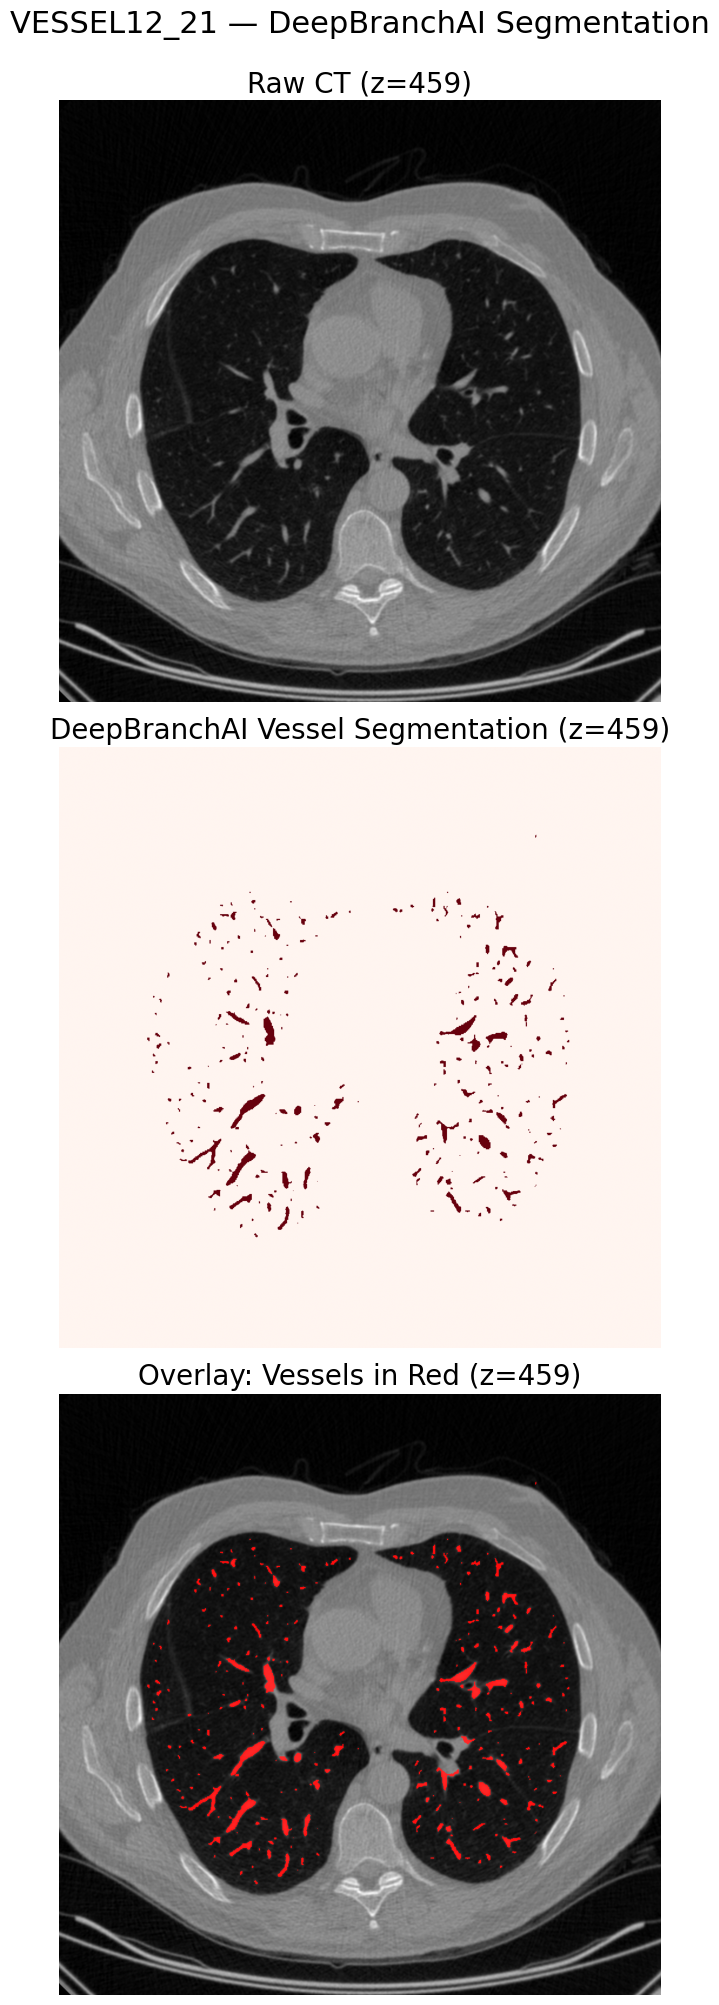

In [10]:
fig, axes = plt.subplots(3, 1, figsize=(18, 20))

axes[0].imshow(vol_raw[mid], cmap='gray')
axes[0].set_title(f'Raw CT (z={mid})', fontsize=20)
axes[0].axis('off')

axes[1].imshow(mask_bin[mid], cmap='Reds', vmin=0, vmax=1)
axes[1].set_title(f'DeepBranchAI Vessel Segmentation (z={mid})', fontsize=20)
axes[1].axis('off')

rgb = np.stack([vol_raw[mid]] * 3, axis=-1).astype(np.float32) / 255
vessel = mask_bin[mid] > 0
rgb[vessel, 0] = 1.0
rgb[vessel, 1] *= 0.3
rgb[vessel, 2] *= 0.3
axes[2].imshow(rgb)
axes[2].set_title(f'Overlay: Vessels in Red (z={mid})', fontsize=20)
axes[2].axis('off')

plt.suptitle('VESSEL12_21 — DeepBranchAI Segmentation', fontsize=22, y=1.0)
plt.tight_layout()
plt.show()

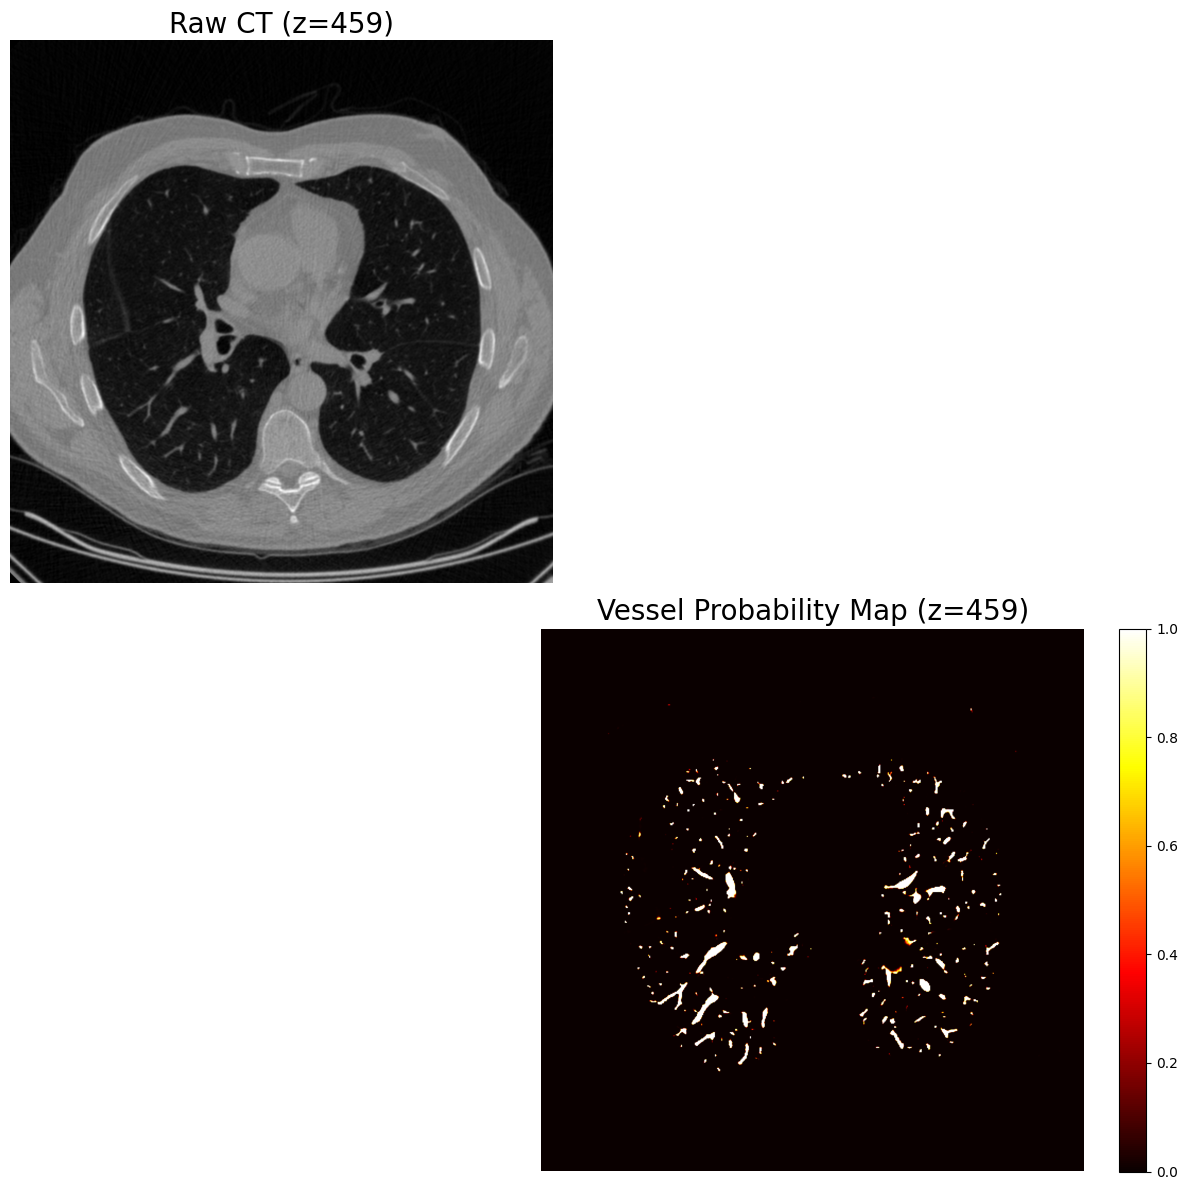

In [11]:
# Probability heatmap
fig, axes = plt.subplots(2, 1, figsize=(18, 12))
axes[0].imshow(vol_raw[mid], cmap='gray')
axes[0].set_title(f'Raw CT (z={mid})', fontsize=20)
axes[0].axis('off')
im = axes[1].imshow(prob_map[mid], cmap='hot', vmin=0, vmax=1)
axes[1].set_title(f'Vessel Probability Map (z={mid})', fontsize=20)
axes[1].axis('off')
plt.colorbar(im, ax=axes[1], fraction=0.02, pad=0.02)
plt.tight_layout()
plt.show()

## Step 5: Validate Against Expert Annotations

In [12]:
# Find annotations
ann_path = None
for p in paths['data'].rglob('VESSEL12_21_Annotations.csv'):
    ann_path = p
    break
if ann_path is None:
    raise FileNotFoundError('VESSEL12_21_Annotations.csv not found')

df = pd.read_csv(str(ann_path), header=None, names=['x', 'y', 'z', 'label'])

# Double coordinates for 2x upscaled volumes
df[['x', 'y', 'z']] = df[['x', 'y', 'z']] * 2
df = df.astype({'x': int, 'y': int, 'z': int, 'label': int})

print(f'Annotation points: {len(df)}  (vessel: {(df.label==1).sum()}, non-vessel: {(df.label==0).sum()})')

Annotation points: 277  (vessel: 78, non-vessel: 199)


In [13]:
# Compute accuracy
zs, ys, xs = df['z'].values, df['y'].values, df['x'].values
true_labels = df['label'].values
pred_labels = mask_bin[zs, ys, xs]

n_pts      = len(true_labels)
n_match    = int((pred_labels == true_labels).sum())
n_vess     = int((true_labels == 1).sum())
n_non      = int((true_labels == 0).sum())
n_vess_mat = int((pred_labels[true_labels == 1] == 1).sum())
n_non_mat  = int((pred_labels[true_labels == 0] == 0).sum())

acc     = n_match / n_pts
v_sens  = n_vess_mat / n_vess
nv_spec = n_non_mat / n_non

print(f'VESSEL12_21 Validation Results')
print(f'==============================')
print(f'  Overall accuracy:       {acc:.2%}')
print(f'  Vessel sensitivity:     {n_vess_mat}/{n_vess} ({v_sens:.2%})')
print(f'  Non-vessel specificity: {n_non_mat}/{n_non} ({nv_spec:.2%})')

VESSEL12_21 Validation Results
  Overall accuracy:       98.19%
  Vessel sensitivity:     74/78 (94.87%)
  Non-vessel specificity: 198/199 (99.50%)


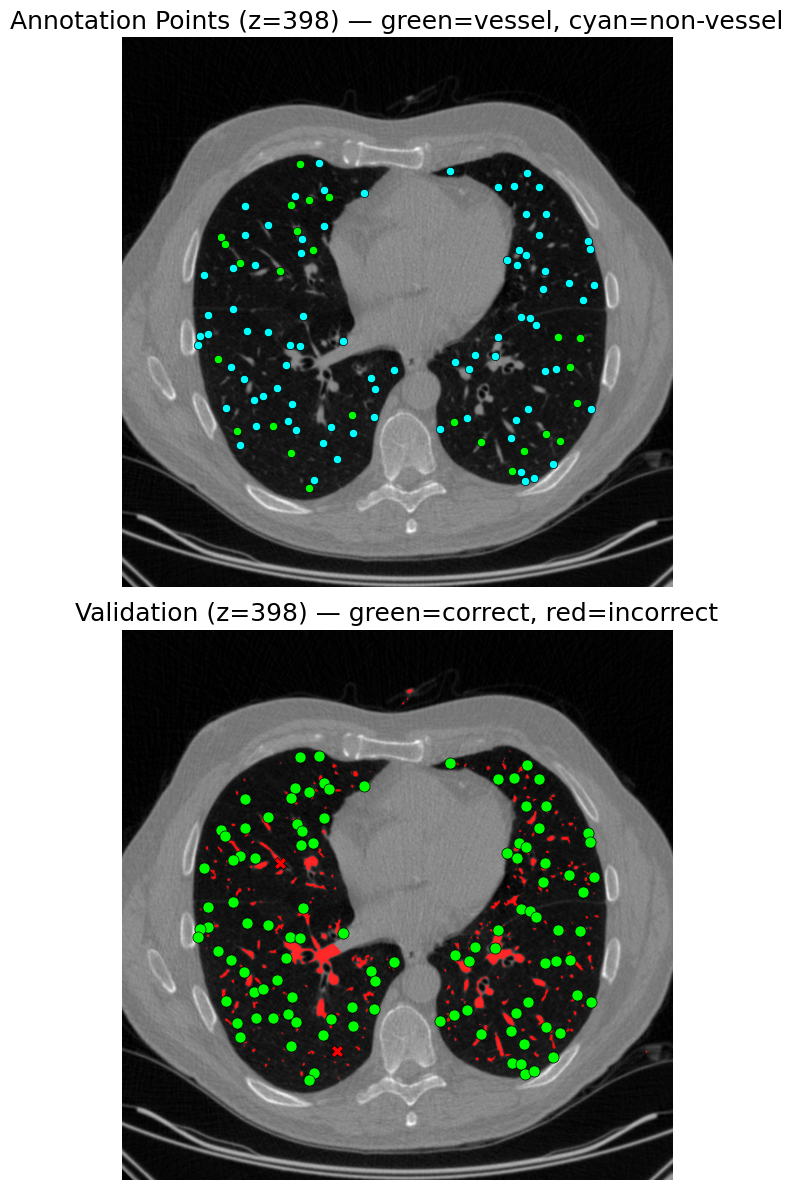

In [14]:
# Visualize annotation validation
ann_slices = sorted(df['z'].unique())
ann_mid = ann_slices[len(ann_slices) // 2]
df_slice = df[df['z'] == ann_mid]

fig, axes = plt.subplots(2, 1, figsize=(18, 12))

axes[0].imshow(vol_raw[ann_mid], cmap='gray')
for _, row in df_slice.iterrows():
    color = 'lime' if row['label'] == 1 else 'cyan'
    axes[0].plot(row['x'], row['y'], 'o', color=color, markersize=6,
                 markeredgecolor='black', markeredgewidth=0.5)
axes[0].set_title(f'Annotation Points (z={ann_mid}) — green=vessel, cyan=non-vessel', fontsize=18)
axes[0].axis('off')

rgb = np.stack([vol_raw[ann_mid]] * 3, axis=-1).astype(np.float32) / 255
vessel = mask_bin[ann_mid] > 0
rgb[vessel, 0] = 1.0; rgb[vessel, 1] *= 0.3; rgb[vessel, 2] *= 0.3
for _, row in df_slice.iterrows():
    correct = mask_bin[row['z'], row['y'], row['x']] == row['label']
    color = 'lime' if correct else 'red'
    marker = 'o' if correct else 'X'
    axes[1].plot(row['x'], row['y'], marker, color=color, markersize=8,
                 markeredgecolor='black', markeredgewidth=0.5)
axes[1].imshow(rgb)
axes[1].set_title(f'Validation (z={ann_mid}) — green=correct, red=incorrect', fontsize=18)
axes[1].axis('off')

plt.tight_layout()
plt.show()

In [15]:
# Summary table
summary = pd.DataFrame([{
    'Volume': 'VESSEL12_21',
    'Accuracy': f'{acc:.2%}',
    'Vessel Sensitivity': f'{v_sens:.2%}',
    'Non-vessel Specificity': f'{nv_spec:.2%}',
    'Points': n_pts,
    'Correct': n_match,
}])
display(summary)

,Volume,Accuracy,Vessel Sensitivity,Non-vessel Specificity,Points,Correct
0,VESSEL12_21,98.19%,94.87%,99.50%,277,272
